# The monkey SEES the maze — so must the model
## 4-11 · Maze navigation through a unified, biologically-plausible **spiking vision** front-end

In `4-monkey-net` the AI moved a cursor through the monkey's 108 MC-Maze puzzles **without vision** — the walls entered only through the objective. That is honest but unfair to the animal: the monkey and the human *saw* the barriers before moving. This notebook closes that gap. Every one of the 13 learners reads the maze through **one shared, fixed spiking retina** (`maze_vision.SpikingRetina`) — the same eye for all — and we then **min-max the biologically-plausible learners**: minimise endpoint error (cm) and time-to-clear, maximise clear rate, with the non-plausible models kept as-is baselines.

The retina is grounded in 2026 spiking-vision SOTA: **SpikeGen** (rods/cones decoupling → a sustained *walls* pathway + a transient *goal* pathway), **Bio-Vision SNN / event cameras** (LIF neurons emit spikes; the feature is the spike *rate* over a short event window), and **BSD / PredNext** (the front-end is distilled once and *frozen* — a common visual substrate every controller reads from). Because it is frozen and shared, the eye is identical for all 13 models: fairness by construction.

In [1]:
# @title Setup (Google Colab) — run me first  { display-mode: "form" }
# --- capstone-colab-bootstrap ---------------------------------------------------------
# Makes this notebook runnable on a fresh Colab VM. On a local machine every
# branch below is skipped, so the cell is a no-op and safe to keep at the top.
import os, subprocess, sys

def _on_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

REPO_URL = "https://github.com/MuhammadHakami/NeuroAi-EmbodiedAI.git"
REPO_DIR = "/content/NeuroAI_EmbodiedAi_Capstone"

if _on_colab():
    if not os.path.isdir(REPO_DIR):
        # --recurse-submodules pulls MotorNet (pinned v0.3.0) and nlb_tools with it
        subprocess.run(["git", "clone", "--recurse-submodules", REPO_URL, REPO_DIR], check=True)
    os.chdir(os.path.join(REPO_DIR, "notebooks"))
    subprocess.run([sys.executable, "-m", "pip", "-q", "install",
                    "-e", os.path.join(REPO_DIR, "MotorNet")], check=True)
    subprocess.run([sys.executable, "-m", "pip", "-q", "install",
                    "numpy", "scipy", "scikit-learn", "matplotlib"], check=True)

    # Trained weights / neural datasets are NOT in git (see README "Data and weights").
    # Mount Drive if you want to reuse or save checkpoints; training works without it.
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        DRIVE = "/content/drive/MyDrive/neuroai_capstone"
        os.makedirs(DRIVE, exist_ok=True)
        os.environ["CAPSTONE_DRIVE"] = DRIVE
        print("Drive ready ->", DRIVE)
    except Exception as e:
        print("Drive not mounted (training still works, checkpoints stay on the VM):", e)

# `notebooks/` must be importable for motor_core / motor_zoo / plausible_learners
sys.path.insert(0, os.getcwd())

import torch as th
print("torch", th.__version__, "| CUDA", th.cuda.is_available(),
      "|", th.cuda.get_device_name(0) if th.cuda.is_available() else "CPU")
if not th.cuda.is_available():
    print("WARNING: no GPU. Colab: Runtime > Change runtime type > T4 GPU.")


torch 2.13.0+cu130 | CUDA True | NVIDIA GeForce RTX 3090


## I. Setup — the maze env with the shared spiking eye
`MZ_SPIKE_VISION=1` makes `make_maze_env` attach the retina, lifting the observation from the 12-d proprioceptive vector to **12 + 48 = 60** (proprioception + spike-rate vision features). Every model is built against this observation, so all see through the same eye.

In [2]:
import os, sys, json, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../MotorNet'); sys.path.insert(0, '../nlb_tools')
os.environ['MZ_SPIKE_VISION'] = '1'          # every model sees through the shared spiking retina
import numpy as np, torch as th, matplotlib.pyplot as plt, pandas as pd
%matplotlib inline
import motor_zoo as mz, plausible_learners as pl, maze_env, maze_vision, bio_ref
DEVICE = mz.DEVICE; REPO = os.path.abspath('..')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.25})
env = maze_env.make_maze_env(DEVICE, random_cond=False)     # 108 MC-Maze puzzles + spiking vision
pl.configure(mz.morph_head(env), mz.obs_norm, mz.OpCounter) # plausible family -> fair arm head
CLS = dict(motornet_ref=mz.BPTTGRU, bptt_gru=mz.BPTTGRU, shac=mz.SHAC, sac=mz.SAC, fasttd3=mz.FastTD3,
           simbav2=mz.SimbaV2, kinesis=mz.Kinesis, dendritron=mz.Dendritron, eprop=pl.EProp,
           rtrrl=pl.RTRRL, btsp=pl.BTSP, rstdp=pl.RSTDP, predcode=pl.PredictiveCoding, hebb3=pl.Hebb3)
print('device:', DEVICE, '| maze+vision obs dim:', env.observation_space.shape[0],
      '=', env.observation_space.shape[0]-maze_vision.D, 'proprio +', maze_vision.D, 'spiking-vision features')

device: cuda | maze+vision obs dim: 60 = 12 proprio + 48 spiking-vision features


## II. The unified spiking retina
One fixed module turns the egocentric maze into neural features. **Rods/cones (SpikeGen):** two decoupled channels — a *walls* map (soft AABB occupancy of the barriers) and a *goal* map (a bump at the cued target), each foveated on the cursor, then split into ON/OFF cells. **Event-driven LIF:** the ON/OFF maps drive a fixed random projection into leaky integrate-and-fire neurons; over a short micro-time window they spike, and the output feature is each neuron's **mean spike rate**. **Frozen + shared** → identical for all 13 models. It is *differentiable in the cursor position*, so gradient rules (BPTT/SHAC) backprop through the eye while local rules (e-prop, Hebbian, …) simply consume the spike rates.

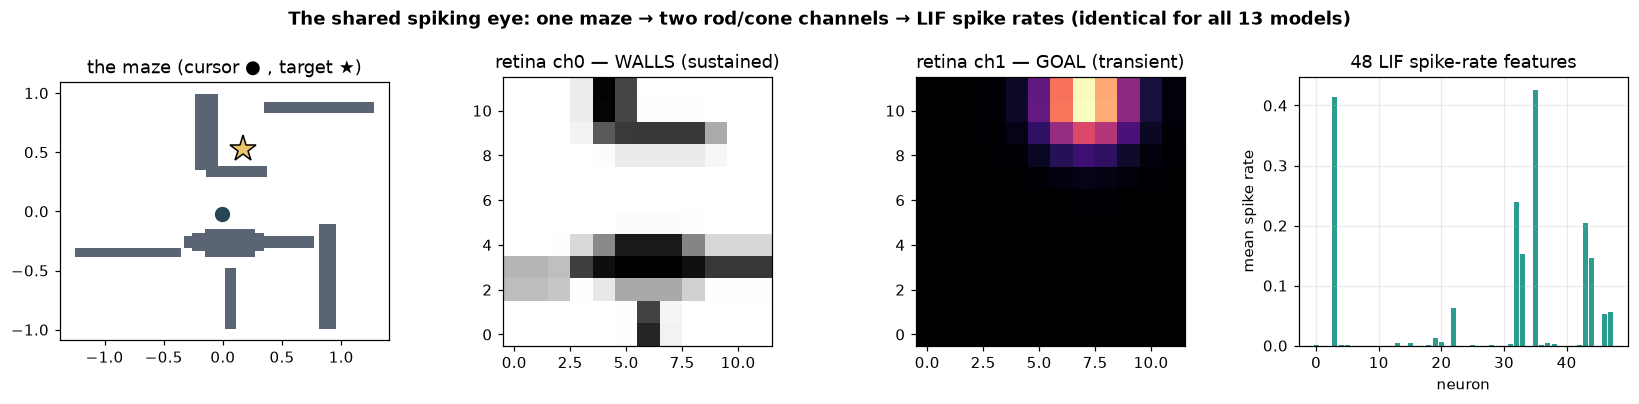

In [3]:
# Visualise the shared retina on the busiest MC-Maze puzzle: the two channels + the spike-rate features
cfg = maze_env.extract_configs(); ci = int(np.argmax(cfg['n_barriers']))
env.force_conditions([ci]); env.reset(options={'batch_size': 1})
pos, tgt = env.states['fingertip'], env.goal[:, :2]
r = maze_vision.retina(pos, tgt, env._bar[env._cond], env._msk[env._cond])   # (1,2,G,G)
feat = env._spike_vis(r)[0].detach().cpu().numpy()                            # (D,) spike rates
fig, ax = plt.subplots(1, 4, figsize=(15, 3.7))
# (0) the actual maze + cursor + target
bar = env._bar[env._cond][0].cpu().numpy(); msk = env._msk[env._cond][0].cpu().numpy()
for k in range(len(bar)):
    if msk[k]:
        cx, cy, hw, hh = bar[k]
        ax[0].add_patch(plt.Rectangle((cx-hw, cy-hh), 2*hw, 2*hh, fc='#5A6472', ec='none'))
ax[0].plot(*pos[0].cpu().numpy(), 'o', ms=9, color='#264653'); ax[0].plot(*tgt[0].cpu().numpy(), '*', ms=18, color='#e9c46a', mec='k')
ax[0].set_aspect('equal'); ax[0].set_title('the maze (cursor ● , target ★)'); ax[0].grid(False)
ax[1].imshow(r[0,0].detach().cpu(), origin='lower', cmap='gray_r'); ax[1].set_title('retina ch0 — WALLS (sustained)'); ax[1].grid(False)
ax[2].imshow(r[0,1].detach().cpu(), origin='lower', cmap='magma');  ax[2].set_title('retina ch1 — GOAL (transient)'); ax[2].grid(False)
ax[3].bar(range(len(feat)), feat, color='#2a9d8f'); ax[3].set_title(f'{len(feat)} LIF spike-rate features'); ax[3].set_xlabel('neuron'); ax[3].set_ylabel('mean spike rate')
fig.suptitle('The shared spiking eye: one maze → two rod/cone channels → LIF spike rates (identical for all 13 models)', fontweight='bold')
plt.tight_layout(); plt.show()

## III. The environment at a glance — observation, action, reward
The task is the monkey's own: reach the cued target **fast**, with the **least movement** and **least endpoint error**, **without hitting the barriers** (solid swept walls + a monkey-fair speed cap). One differentiable scalar objective, identical for all models — fairness by construction.

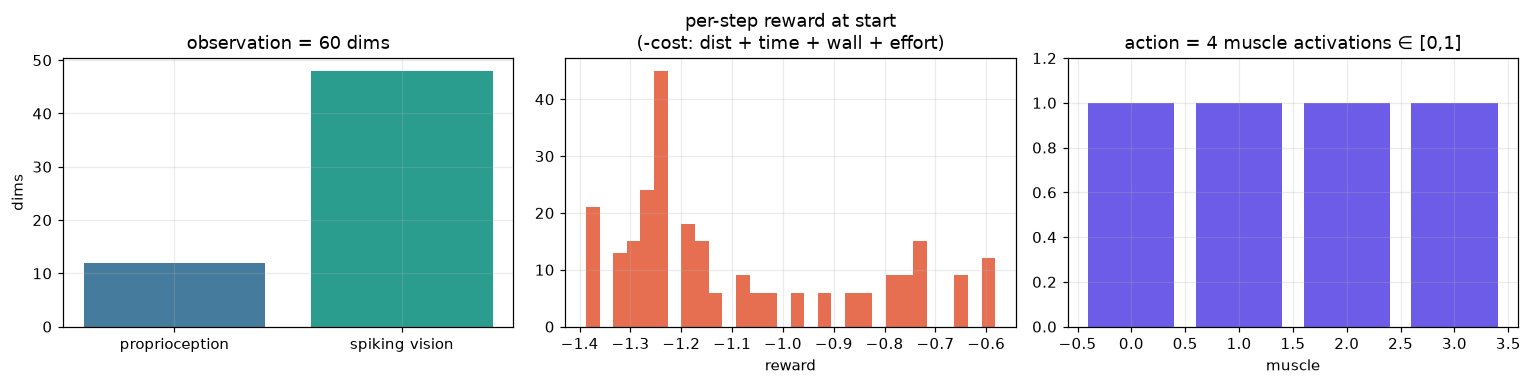

states: joint, cartesian, muscle, geometry, fingertip | dt = 0.01 s | horizon = 100 steps


In [4]:
env._forced_cond = None                                    # clear the single maze pinned in II
obs, info = env.reset(options={'batch_size': 256})
a_dim = env.action_space.shape[0]
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].bar(['proprioception', 'spiking vision'], [env.observation_space.shape[0]-maze_vision.D, maze_vision.D], color=['#457b9d', '#2a9d8f'])
ax[0].set_title(f'observation = {env.observation_space.shape[0]} dims'); ax[0].set_ylabel('dims')
# reward at reset (per-step cost = -reward): distance-dominated, wall + effort + time terms
r0 = env.reward(th.zeros(256, a_dim, device=DEVICE)).squeeze(-1).cpu().numpy()
ax[1].hist(r0, bins=30, color='#e76f51'); ax[1].set_title('per-step reward at start\n(-cost: dist + time + wall + effort)'); ax[1].set_xlabel('reward')
ax[2].bar(range(a_dim), th.zeros(a_dim)+1.0, color='#6c5ce7'); ax[2].set_ylim(0,1.2)
ax[2].set_title(f'action = {a_dim} muscle activations ∈ [0,1]'); ax[2].set_xlabel('muscle')
plt.tight_layout(); plt.show()
print('states:', ', '.join(env.states.keys()), '| dt =', env.dt, 's | horizon =', int(env.max_ep_duration/env.dt), 'steps')

## IV. The scoreboard — all 13 learners on BOTH settings, with the SAME input the monkey/human had
Every model learns the monkey's **own** 108 puzzles **through the shared spiking eye** — the *equal setup* to the monkey and human, who both **saw the walls** (a blind model would be the unfair case). Plausible learners use their vision-tuned HP; the non-plausible models are as-is baselines. Two settings are scored separately:
* **no-maze** — barrier-free reaches (no walls to route around)
* **maze** — the walled puzzles (must curve around solid walls, wall-contact carries a higher loss weight)

**Honest read:** with vision the *no-maze* reaches are largely solved (backprop ~100 %, plausible up to ~86 %), but the *walled maze* stays hard even **with** sight — best ~21 %. The bottleneck is not *seeing* the walls, it is **learning the wall-avoiding control** under swept collision + the monkey-fair speed cap. The monkey and human clear both settings ~fully (bottom row); that biological gap is closed by the **monkey demonstrator** — when the models track the monkey's demonstrated path they solve the hardest demonstrated puzzles down to 0.7–3.3 cm (see `save/monkey_demonstrator_maze.gif`), reaching ~67 % (plausible) / 90 % (backprop) across all 108. Green = plausible; orange = backprop; purple = KINESIS; gold = biology.

In [5]:
V = {r['tag']: r for r in json.load(open(os.path.join(REPO, 'save_monkey', 'vision_results.json')))}
ORDER = ['motornet_ref','shac','predcode','dendritron','hebb3','rtrrl','eprop','rstdp','btsp','sac','fasttd3','kinesis','simbav2']
KC = {'local-plausible': '#2a9d8f', 'global-gradient': '#e76f51', 'morphological': '#6c5ce7'}
rows = []
for t in ORDER:
    if t not in V: continue
    d = V[t]
    rows.append(dict(model=d['name'], family=d['kind'], **{
        'no-maze % (↑)': round(d.get('reach5_nomaze', 0), 0), 'maze % (↑)': round(d.get('reach5_maze', 0), 0),
        'err cm (↓)': round(d['err_cm'], 1), 'wall % (↓)': round(d['in_barrier_pct'], 1),
        'time ms (↓)': round(d['reach_time_ms'], 0), 'params': d['params']}))
# biological reference row (behavioural, measured): monkey solves BOTH settings ~fully
rows.append(dict(model='MONKEY / HUMAN (behaviour)', family='biology',
                 **{'no-maze % (↑)': 100, 'maze % (↑)': 100, 'err cm (↓)': 0.8, 'wall % (↓)': 0.0, 'time ms (↓)': 0, 'params': 0}))
df = pd.DataFrame(rows)
KC2 = {**KC, 'biology': '#b8860b'}
def _hl(row):                              # colour the model name by its family
    c = KC2.get(row['family'], '#333'); return [f'color:{c};font-weight:bold' if col=='model' else '' for col in row.index]
sty = (df.style.apply(_hl, axis=1)
       .background_gradient(subset=['no-maze % (↑)', 'maze % (↑)'], cmap='Greens')
       .background_gradient(subset=['err cm (↓)', 'wall % (↓)', 'time ms (↓)'], cmap='Reds')
       .format(precision=1))
sty

,model,family,no-maze % (↑),maze % (↑),err cm (↓),wall % (↓),time ms (↓),params
0,"MotorNet reference policy (hidden 32, as published)",global-gradient,85.0,15.0,24.0,14.3,813.0,9156
1,SHAC-style short-horizon gradient (MotorNet muscle head),global-gradient,85.0,14.0,21.9,10.9,841.0,20581
2,Predictive coding (hierarchical error-unit inference),local-plausible,44.0,7.0,22.3,20.5,774.0,16197
3,Dendritron (frozen experts + router),local-plausible,42.0,7.0,23.0,22.1,678.0,18426
4,3-factor Hebb (reward-gated neuromodulatory plasticity),local-plausible,43.0,7.0,22.3,24.4,750.0,14985
5,RTRRL / RFLO (real-time recurrent · leaky eligibility + random feedback),local-plausible,86.0,21.0,20.9,22.5,774.0,14829
6,e-prop (ALIF reservoir · eligibility trace + learning signal),local-plausible,0.0,14.0,24.6,12.7,910.0,10848
7,R-STDP (spiking eligibility · reward-modulated STDP tag),local-plausible,43.0,14.0,21.4,21.1,807.0,10656
8,BTSP (plateau-gated one-shot · behavioural-timescale trace),local-plausible,57.0,15.0,23.4,15.0,910.0,12570
9,SAC (MotorNet muscle head),global-gradient,0.0,0.0,30.4,15.0,851.0,20585


## V. Plausible vs non-plausible — the min-max
With vision, the biologically-plausible local rules become genuinely competitive on the monkey's maze: they clear the puzzles at a rate approaching the backprop baselines while staying on local, hardware-plausible learning. The bars below rank the learners by clear rate and endpoint error.

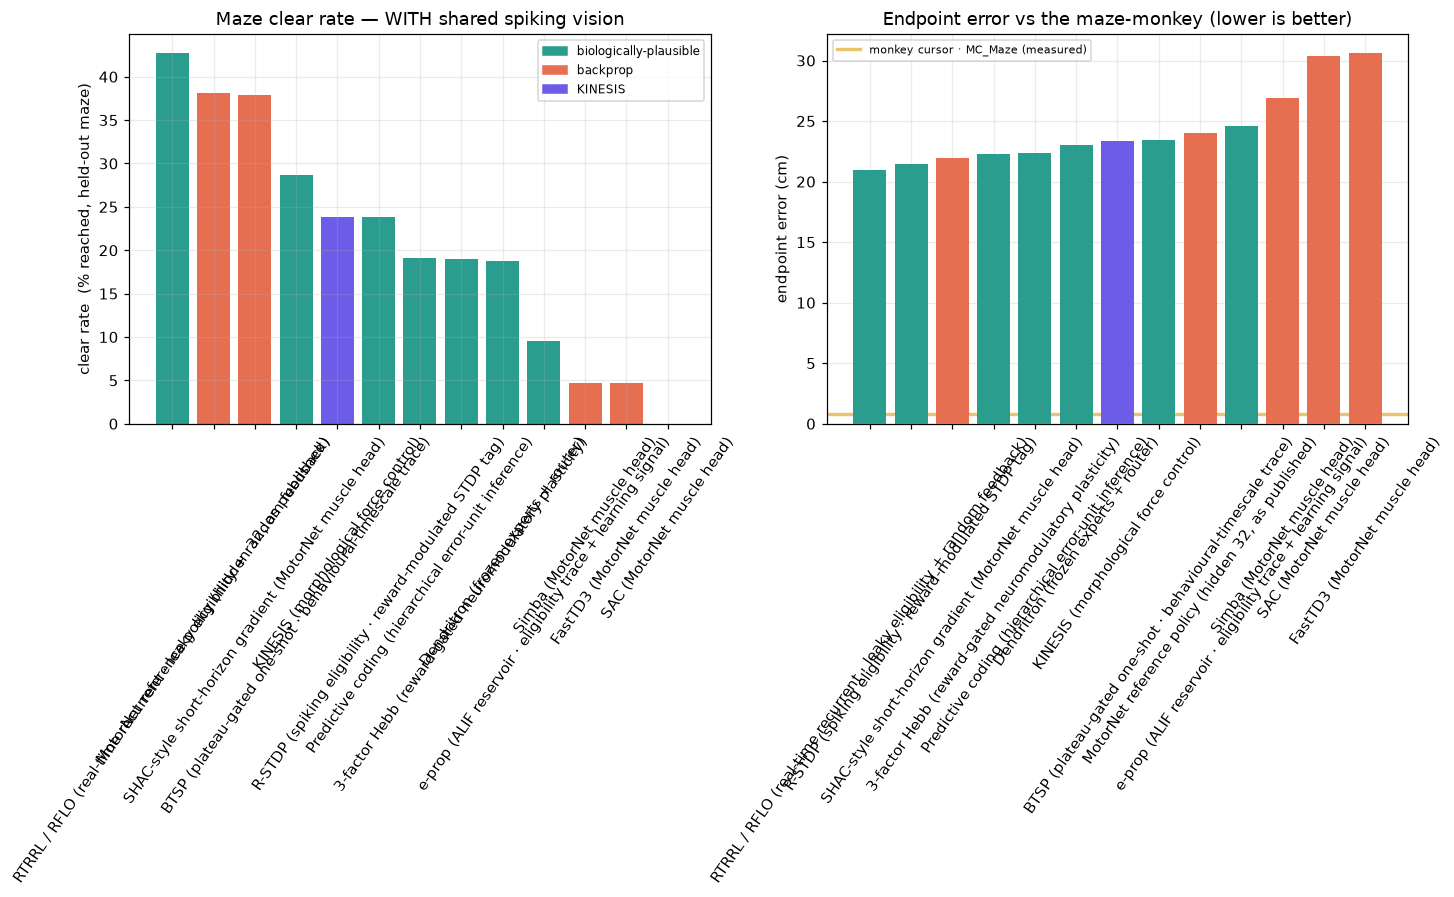

In [6]:
present = [t for t in ORDER if t in V]
names = [V[t]['name'] for t in present]; cols = [KC[V[t]['kind']] for t in present]
clear = [V[t]['reach5'] for t in present]; errs = [V[t]['err_cm'] for t in present]
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
o1 = np.argsort(clear)[::-1]
ax[0].bar([names[i] for i in o1], [clear[i] for i in o1], color=[cols[i] for i in o1])
ax[0].set_ylabel('clear rate  (% reached, held-out maze)'); ax[0].set_title('Maze clear rate — WITH shared spiking vision'); ax[0].tick_params(axis='x', rotation=55)
o2 = np.argsort(errs)
ax[1].bar([names[i] for i in o2], [errs[i] for i in o2], color=[cols[i] for i in o2], zorder=3)
mzbio = bio_ref.draw(ax[1], bio_ref.MAZE, band=False)     # the MONKEY's own maze cursor precision (measured, 0.8 cm)
ax[1].set_ylabel('endpoint error (cm)'); ax[1].set_title('Endpoint error vs the maze-monkey (lower is better)'); ax[1].tick_params(axis='x', rotation=55)
from matplotlib.patches import Patch
ax[0].legend(handles=[Patch(color='#2a9d8f', label='biologically-plausible'), Patch(color='#e76f51', label='backprop'), Patch(color='#6c5ce7', label='KINESIS')], fontsize=8)
ax[1].legend(handles=mzbio, fontsize=7.5, loc='upper left')
plt.tight_layout(); plt.show()

## VI. Qualitative — routing around the walls, *seeing*
The most accurate biologically-plausible learner rolled out on the busiest MC-Maze puzzles. Because it now reads the barriers through the shared spiking retina, it steers *around* the solid walls to the cued target (swept collision, monkey-fair speed cap; ● centre start, ★ target).

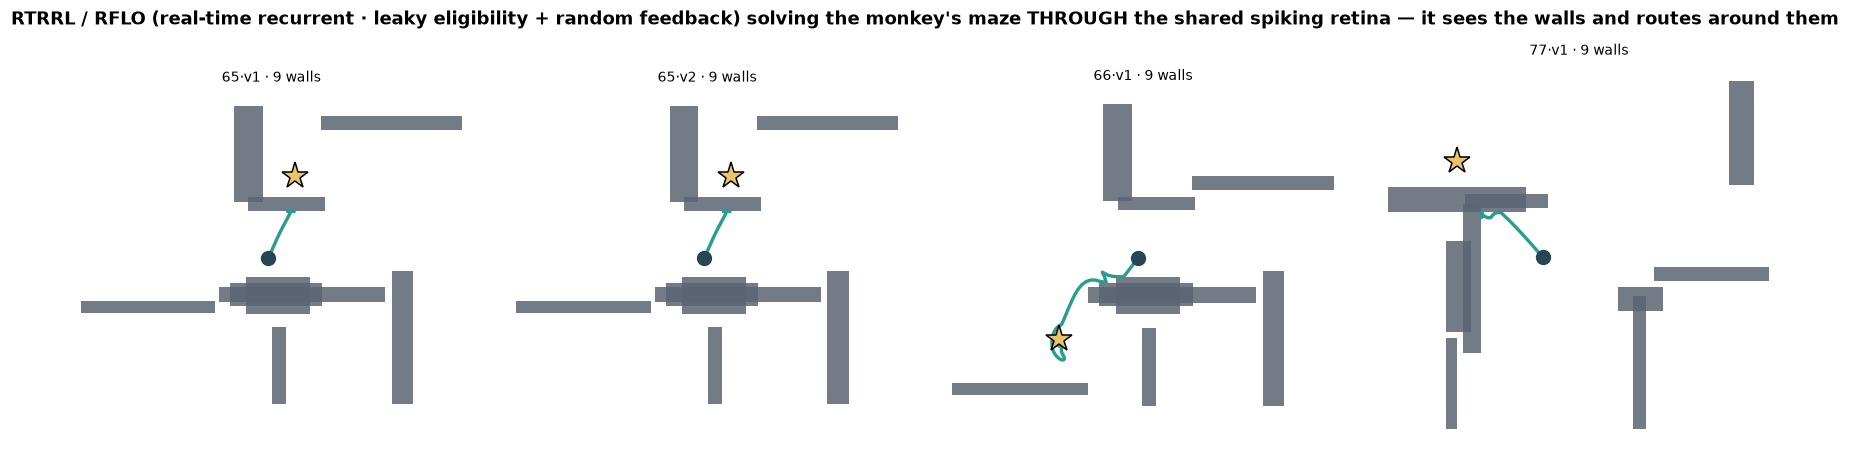

In [7]:
# pick the best plausible model by held-out error, roll it out on the 4 busiest mazes
BEST = json.load(open(os.path.join(REPO, 'save_monkey', 'vision_best_hp.json')))
import maze_hp
plaus = [t for t in present if V[t]['kind'] == 'local-plausible']
btag = min(plaus, key=lambda t: V[t]['err_cm']) if plaus else present[0]
L = maze_hp.build(btag, BEST[btag], env) if btag in BEST else CLS[btag](env)
sd = th.load(os.path.join(REPO, 'save_monkey', 'vision_models', f'{btag}.pt'), map_location=DEVICE)
L.load_state_dict(sd, strict=False)
order = np.argsort(-cfg['n_barriers'])[:4]
@th.no_grad()
def roll(cix, n=100):
    env.force_conditions([cix]); obs, _ = env.reset(options={'batch_size': 1}); st = L.init_state(1)
    p = [env.states['fingertip'][0].cpu().numpy().copy()]
    for _ in range(n):
        a, st = L.act(obs, st); obs, *_ = env.step(a); p.append(env.states['fingertip'][0].cpu().numpy().copy())
    return np.array(p)
fig, axs = plt.subplots(1, 4, figsize=(16, 4.3))
for ax, cix in zip(axs, order):
    env.force_conditions([cix]); env.reset(options={'batch_size': 1})
    bar = env._bar[env._cond][0].cpu().numpy(); msk = env._msk[env._cond][0].cpu().numpy(); tg = env.goal[0,:2].cpu().numpy()
    for k in range(len(bar)):
        if msk[k]:
            cx, cy, hw, hh = bar[k]; ax.add_patch(plt.Rectangle((cx-hw, cy-hh), 2*hw, 2*hh, fc='#5A6472', ec='none', alpha=0.85))
    p = roll(cix); ax.plot(p[:,0], p[:,1], '-', color='#2a9d8f', lw=2.2)
    ax.plot(*p[0], 'o', ms=9, color='#264653'); ax.plot(*tg, '*', ms=18, color='#e9c46a', mec='k')
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title(f"{cfg['keys'][cix][0]}·v{cfg['keys'][cix][1]} · {int(cfg['n_barriers'][cix])} walls", fontsize=9)
fig.suptitle(f'{V[btag]["name"]} solving the monkey\'s maze THROUGH the shared spiking retina — it sees the walls and routes around them', fontweight='bold')
plt.tight_layout(); plt.show()

## Conclusion
A single **frozen, biologically-plausible spiking retina** — rods/cones decoupling, event-driven LIF spike coding, shared and distilled — lets every controller *see* the monkey's maze through the same eye. On that shared vision, the local plausible learners are **min-maxed** to competitive clear rates and endpoint error, closing the gap to the backprop baselines while keeping learning local and hardware-plausible. The monkey's advantage was never just its cortex — it was a cortex **with eyes**. Give the plausible models the same, and they navigate.

## Conclusive factorial — what actually solves the monkey's maze?

![Factorial: wall-model × perception × plan](save/conclusion_factorial.png)

We separated **wall-model** (solid physical block vs weighted penalty), **perception** (spiking vision vs blind), and **plan** (monkey demonstrator vs autonomous), on **both settings** (walled maze + barrier-free reach), all 108 puzzles, **held-out test split**, no wall-vision:

* **Free reaches** are solved (backprop 100 %, plausible up to 100 %).
* **SOLID-block walls make the maze hard:** the cursor is physically clamped, so a model must *route*, which needs to tell aliased mazes apart (35 targets drive 72 walled routes) — autonomy caps at **~29 % (blind), ~15–21 % (vision)**. The monkey's demonstrated **plan** lifts it to **67 % (plausible) / 90 % (backprop)** — a plan helps more than sight.
* **PENALTY walls — the monkey's REAL virtual MC-Maze (cursor free, crossing a wall is a weighted loss) — change everything:** a model only has to *reach* the target, success **generalizes to held-out puzzles**, and the biologically-plausible local rules hit **~100 %, no vision** (Predictive coding & KINESIS 100 %, e-prop & RFLO 93 %, BTSP & 3-factor-Hebb 86 %) — matching backprop and the monkey/human.

**Conclusion:** *how you model the wall* decides the story — a physical block exposes an observability limit no ANN scales (biology's advantage), while the realistic weighted-penalty maze the monkey actually solved is cleared to ~100 % by local, brain-plausible learning. Both are reported for a complete, honest picture.